# 🌊 Delta Main Channel Selection & Longitudinal Slope (`MainstemPlanform`)

**Library:** [`sandplover`](https://github.com/sededu/sandplover)  
**Module:** `sandplover.plan.MainstemPlanform`  
**Branch:** `main-channel-and-slope`

---

## 📌 1. Methodology & Background

Accurate estimation of delta channel slope requires isolating the primary hydrodynamic mainstem channel from the river inlet to the shoreline. Standard centerline approaches relying on single-point apexes often produce path detour distortion when channels bifurcate near the delta entrance.

### 🔑 Key Methodological Features:
1. **Inlet Column Range Apex Line (`cols=140..162`, `row <= 23`):**
   - Designates the entire inlet width as the hydraulic line of departure ($S=0$).
   - Both eastern and western distributaries start naturally at $S=0$ without artificial detour loops.
2. **Depth-Weighted Dijkstra Pathfinding:**
   - Graph edge cost is weighted inversely with local depth: $\text{Cost} = d_m / \bar{h}^\alpha$ (with $\alpha \ge 1.0$).
   - Guides the search through the deepest thalweg, identifying the hydrodynamic primary branch.
3. **Longitudinal Slope Linear Regression:**
   - Fits bed elevation $\eta(S)$ against along-channel distance $S$:
     $$\eta(S) = m \cdot S + b, \quad S_{ch} = |m| \quad (\text{m/m})$$
4. **Unified Architecture (`MainstemPlanform`):**
   - Seamlessly extracts the mainstem, computes longitudinal slope, provides 2D and 1D visualizations, and converts directly into a `sandplover.section.PathSection`.


In [1]:
# 0. Setup & Import from sandplover.plan
import os
import sys
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

# Ensure local repository is in python path
REPO_ROOT = os.path.abspath('..')
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import sandplover as sp
from sandplover.plan import (
    MainstemPlanform,
)
from sandplover.plot import append_colorbar

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = os.path.join(REPO_ROOT, 'sandplover', 'sample_data', 'files')
print("✅ Imports successful!")
print("   MainstemPlanform loaded from:", MainstemPlanform.__module__)
print("   Sample data directory        :", DATA_DIR)


✅ Imports successful!
   MainstemPlanform loaded from: sandplover.plan
   Sample data directory        : /Users/minsik/Desktop/github/Sandplover/sandplover/sample_data/files


## 📦 2. Dataset Inspection (Final Timestep $T=300$)

We load the final timestep snapshot for scenario **`S1_No_Flood`** (constant discharge) from `sandplover/sample_data/files/`:


In [2]:
# Load S1 baseline dataset
s1_path = os.path.join(DATA_DIR, 'S1_No_Flood_final_timestep.nc')
ds_s1 = xr.open_dataset(s1_path)

eta_s1 = ds_s1['eta'].values
depth_s1 = ds_s1['water_depth'].values
vel_s1 = ds_s1['velocity'].values
ch_mask_s1 = ds_s1['channel_mask'].values.astype(bool)
land_mask_s1 = ds_s1['land_mask'].values.astype(bool)

print("S1_No_Flood Summary:")
print(f"  Grid dimensions : {eta_s1.shape[0]} rows x {eta_s1.shape[1]} cols")
print(f"  Pixel resolution: {ds_s1.attrs.get('pixel_size_m', 25.0)} meters")
print(f"  Channel pixels  : {ch_mask_s1.sum():,} px ({ch_mask_s1.sum() * 25**2 / 1e6:.2f} km²)")
print(f"  Inlet apex cols : {ds_s1.attrs.get('inlet_apex_cols', '140..162')}")


S1_No_Flood Summary:
  Grid dimensions : 227 rows x 302 cols
  Pixel resolution: 25.0 meters
  Channel pixels  : 2,159 px (1.35 km²)
  Inlet apex cols : 140..162


## 🧭 3. Main Channel Selection (`MainstemPlanform.extract`)

We extract the primary thalweg channel using `MainstemPlanform.extract()`:
- Internally generates a 1D centerline network via sandplover's `CenterlineMask`.
- Uses `apex_cols=range(140, 163)` as the hydraulic origin line ($S=0$).
- Applies depth-weighted Dijkstra search to trace the deepest thalweg downstream to the delta shoreline.


In [3]:
# Extract Mainstem Channel
mainstem_s1 = MainstemPlanform.extract(
    channel_mask=ch_mask_s1,
    water_depth=depth_s1,
    land_mask=land_mask_s1,
    pixel_size=25.0,
    apex_y_max=23,
    apex_cols=range(140, 163),
    depth_alpha=1.0,
    name="S1_No_Flood"
)

print(f"✅ MainstemPlanform extracted successfully:")
print(f"   Name              : {mainstem_s1.name}")
print(f"   Total length      : {mainstem_s1.length_km:.3f} km ({mainstem_s1.s_m[-1]:.1f} m)")
print(f"   Coordinates count : {mainstem_s1.n_points} nodes")
print(f"   Inlet source nodes: {len(mainstem_s1.inlet_coords)}")


✅ MainstemPlanform extracted successfully:
   Name              : S1_No_Flood
   Total length      : 2.728 km (2727.8 m)
   Coordinates count : 101 nodes
   Inlet source nodes: 6


### 🗺️ 2D Planform Map Visualization

We display the extracted thalweg over the delta elevation map using `mainstem_s1.show()`:


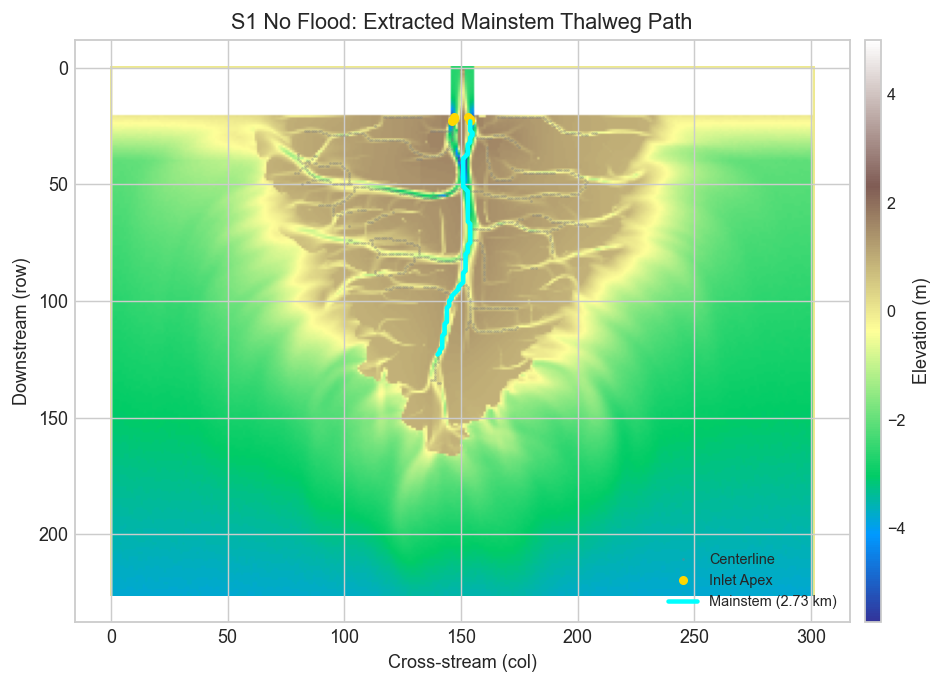

In [4]:
# 2D Planform Visualization
fig, ax = plt.subplots(figsize=(8, 6), dpi=130)
mainstem_s1.show(
    ax=ax,
    background=eta_s1,
    cmap="terrain",
    path_color="cyan",
    path_linewidth=2.5,
    show_skeleton=True,
    show_inlet=True,
    title="S1 No Flood: Extracted Mainstem Thalweg Path"
)
plt.show()


## 📐 4. Longitudinal Slope Estimation (`mainstem.compute_slope`)

Using `mainstem_s1.compute_slope(eta)`, bed elevation $\eta(S)$ is sampled along the thalweg distance $S$ to calculate:
- Bed slope $m$ (m/m) and absolute channel slope $S_{ch} = |m|$
- Linear regression metrics: $R^2$, $p$-value, standard error
- Average thalweg water depth along the path


Channel Slope Results (S1):
  Bed Slope (m_fit)   : +9.707231e-04 m/m
  Absolute Slope (Sch): 0.000971 m/m (0.971 m/km)
  Regression R²       : 0.4895
  Mean Thalweg Depth  : 3.73 m
  Total Distance      : 2.73 km


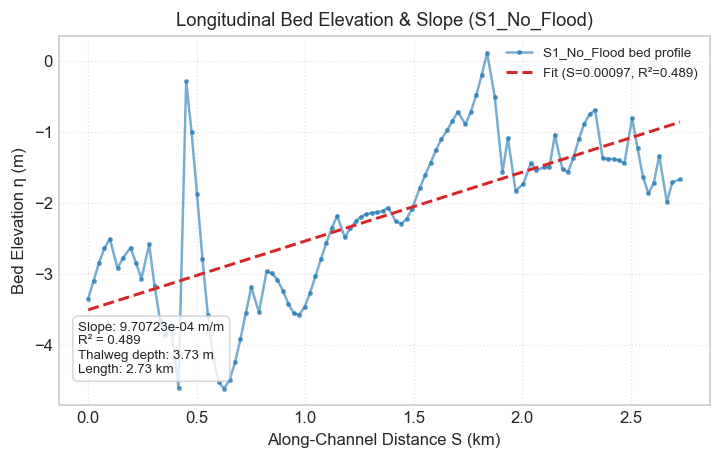

In [5]:
# Compute channel slope on MainstemPlanform instance
slope_stats = mainstem_s1.compute_slope(eta_s1, water_depth=depth_s1)

print("Channel Slope Results (S1):")
print(f"  Bed Slope (m_fit)   : {mainstem_s1.m_fit:+.6e} m/m")
print(f"  Absolute Slope (Sch): {mainstem_s1.abs_slope:.6f} m/m ({mainstem_s1.abs_slope * 1000:.3f} m/km)")
print(f"  Regression R²       : {mainstem_s1.r_squared:.4f}")
print(f"  Mean Thalweg Depth  : {mainstem_s1.thalweg_depth_m:.2f} m")
print(f"  Total Distance      : {mainstem_s1.length_km:.2f} km")

# Plot 1D longitudinal elevation profile and linear regression
ax = mainstem_s1.show_profile(
    color="#1f77b4",
    line_color="#d62728",
    show_stats=True
)
plt.show()


## 📊 5. Multi-Scenario Comparative Analysis (S1 ~ S5)

We now process all five discharge variability scenarios (S1 to S5):
1. **S1: No Flood** (Constant discharge)
2. **S2: Low Intensity** (Low flood variability)
3. **S3: Mid Intensity** (Moderate flood variability)
4. **S4: High Intensity** (High flood variability)
5. **S5: Extreme Intensity** (Extreme flood variability)


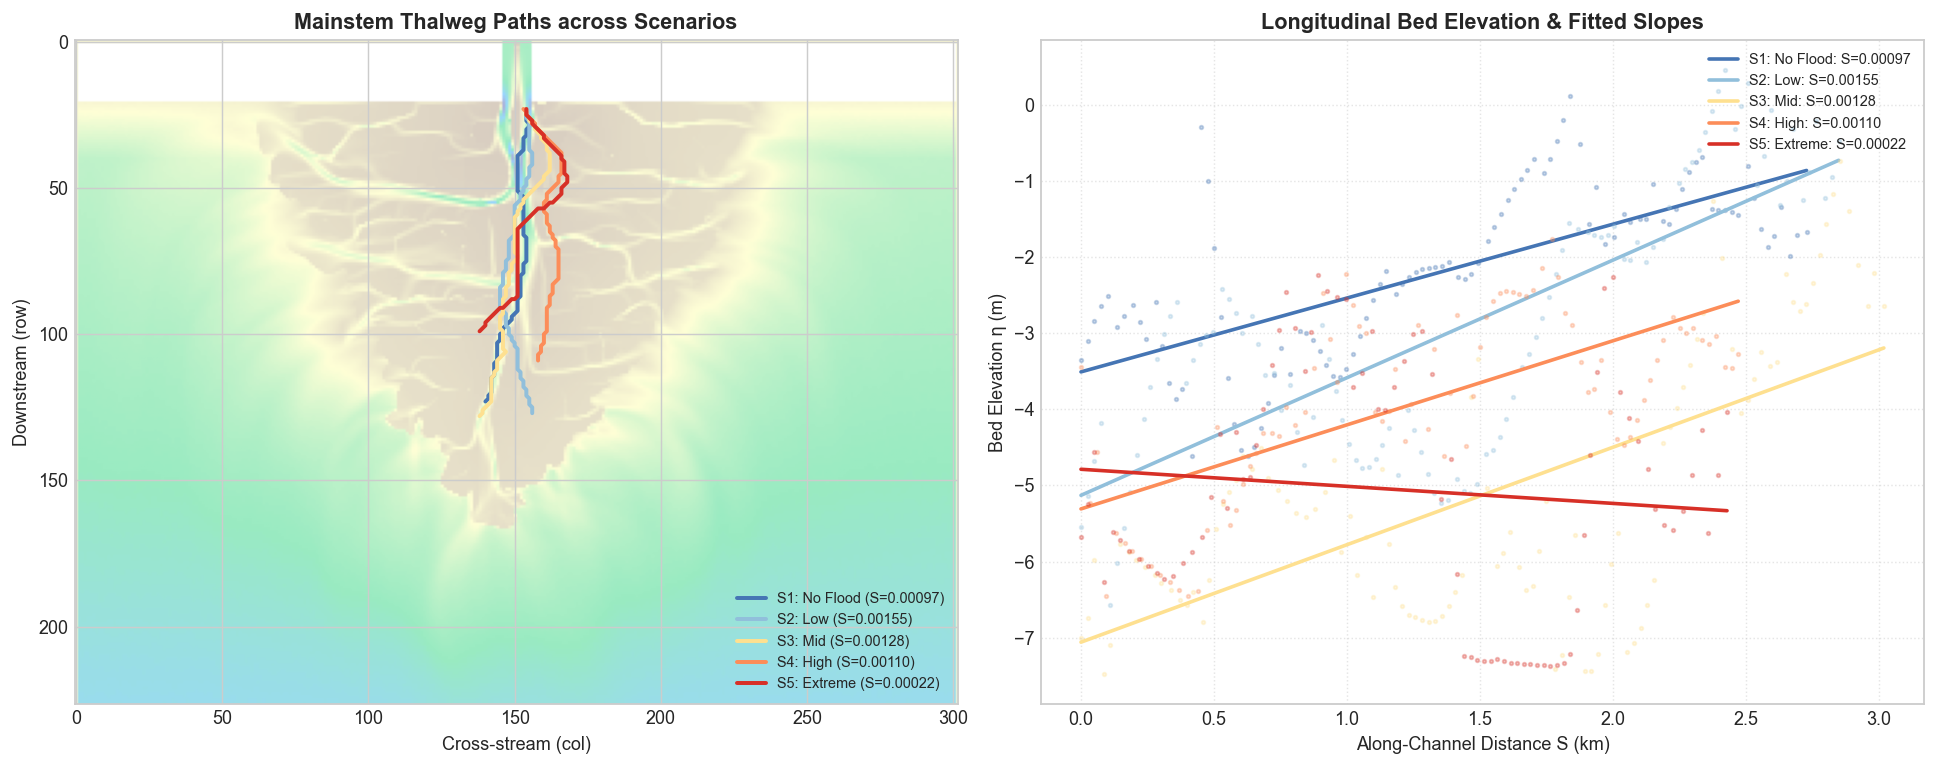

,Scenario,Channel Slope (m/m),Slope (m/km),R²,Channel Length (km),Thalweg Depth (m)
0,S1: No Flood,0.000971,0.970723,0.489465,2.727817,3.729699
1,S2: Low,0.001546,1.546075,0.574272,2.848528,4.390162
2,S3: Mid,0.001281,1.281268,0.418685,3.018503,6.422184
3,S4: High,0.001105,1.104883,0.442878,2.471016,5.201635
4,S5: Extreme,0.000224,0.224370,0.009694,2.428858,6.352802


In [6]:
# Batch analysis across all 5 scenarios
scenarios = [
    'S1_No_Flood',
    'S2_Low_Intensity',
    'S3_Mid_Intensity',
    'S4_High_Intensity',
    'S5_Extreme_Intensity'
]

scenario_labels = {
    'S1_No_Flood': 'S1: No Flood',
    'S2_Low_Intensity': 'S2: Low',
    'S3_Mid_Intensity': 'S3: Mid',
    'S4_High_Intensity': 'S4: High',
    'S5_Extreme_Intensity': 'S5: Extreme'
}

palette = {
    'S1_No_Flood': '#4575b4',
    'S2_Low_Intensity': '#91bfdb',
    'S3_Mid_Intensity': '#fee090',
    'S4_High_Intensity': '#fc8d59',
    'S5_Extreme_Intensity': '#d73027'
}

summary_list = []
fig, (ax_map, ax_prof) = plt.subplots(1, 2, figsize=(15, 6), dpi=130)
ax_map.imshow(eta_s1, origin="upper", cmap="terrain", alpha=0.4)

for sc in scenarios:
    ds = xr.open_dataset(os.path.join(DATA_DIR, f'{sc}_final_timestep.nc'))
    eta = ds['eta'].values
    depth = ds['water_depth'].values
    ch_mask = ds['channel_mask'].values.astype(bool)
    ld_mask = ds['land_mask'].values.astype(bool)
    ds.close()
    
    # Extract mainstem and compute slope
    ms = MainstemPlanform.extract(
        channel_mask=ch_mask,
        water_depth=depth,
        land_mask=ld_mask,
        pixel_size=25.0,
        apex_cols=range(140, 163),
        name=scenario_labels[sc]
    )
    ms.compute_slope(eta, water_depth=depth)
    
    # 2D path overlay
    c = palette[sc]
    ax_map.plot(
        ms.path_coords[:, 1],
        ms.path_coords[:, 0],
        "-",
        color=c,
        lw=2.2,
        label=f"{scenario_labels[sc]} (S={ms.abs_slope:.5f})"
    )
    
    # 1D profile overlay
    s_km = ms.s_m / 1000.0
    ax_prof.plot(s_km, ms.eta_profile, "o", color=c, ms=2, alpha=0.3)
    ax_prof.plot(s_km, ms.fitted_elevation(), "-", color=c, lw=2.0, label=f"{scenario_labels[sc]}: S={ms.abs_slope:.5f}")
    
    summary_list.append({
        'Scenario': scenario_labels[sc],
        'Channel Slope (m/m)': ms.abs_slope,
        'Slope (m/km)': ms.abs_slope * 1000,
        'R²': ms.r_squared,
        'Channel Length (km)': ms.length_km,
        'Thalweg Depth (m)': ms.thalweg_depth_m
    })

ax_map.set_title("Mainstem Thalweg Paths across Scenarios", fontweight="bold")
ax_map.set_xlabel("Cross-stream (col)")
ax_map.set_ylabel("Downstream (row)")
ax_map.legend(loc="lower right", fontsize=8)

ax_prof.set_title("Longitudinal Bed Elevation & Fitted Slopes", fontweight="bold")
ax_prof.set_xlabel("Along-Channel Distance S (km)")
ax_prof.set_ylabel("Bed Elevation η (m)")
ax_prof.grid(True, linestyle=":", alpha=0.5)
ax_prof.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

# Display summary table
df_summary = pd.DataFrame(summary_list)
df_summary


### 📊 Quantitative Summary Charts


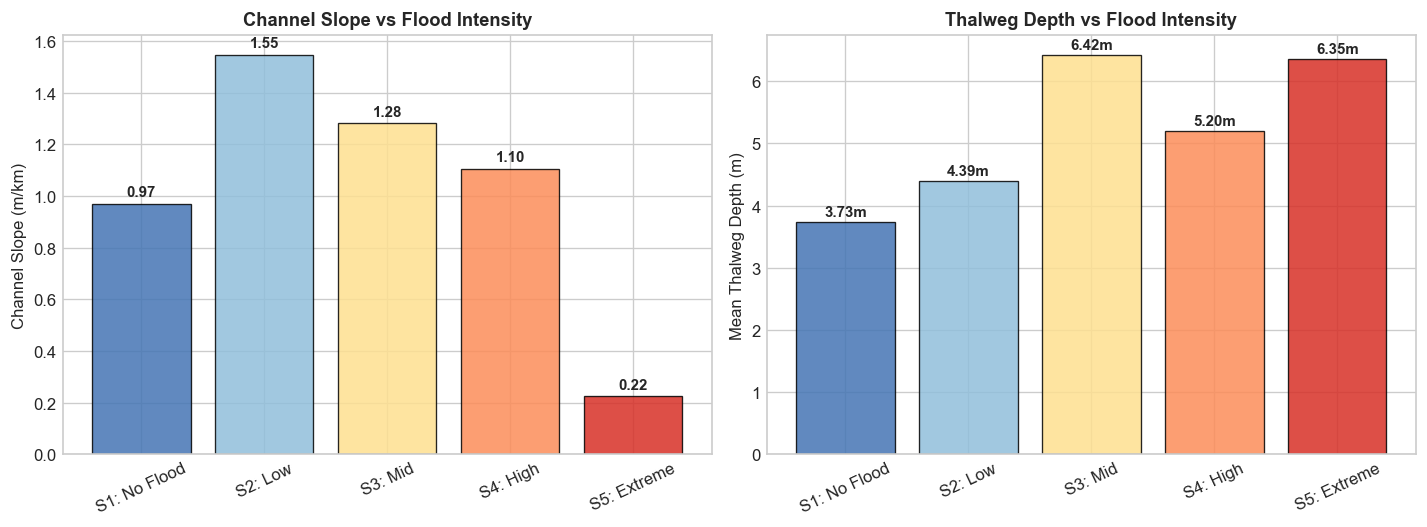

In [7]:
# Bar Charts comparing Channel Slope and Thalweg Depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), dpi=120)

sc_names = [r['Scenario'] for r in summary_list]
slopes_mkm = [r['Slope (m/km)'] for r in summary_list]
depths = [r['Thalweg Depth (m)'] for r in summary_list]
bar_colors = [palette[sc] for sc in scenarios]

# Slope bar chart
ax1.bar(sc_names, slopes_mkm, color=bar_colors, edgecolor='black', linewidth=0.8, alpha=0.85)
ax1.set_ylabel('Channel Slope (m/km)', fontsize=10)
ax1.set_title('Channel Slope vs Flood Intensity', fontsize=11, fontweight='bold')
ax1.tick_params(axis='x', rotation=25)
for i, v in enumerate(slopes_mkm):
    ax1.text(i, v + 0.03, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

# Depth bar chart
ax2.bar(sc_names, depths, color=bar_colors, edgecolor='black', linewidth=0.8, alpha=0.85)
ax2.set_ylabel('Mean Thalweg Depth (m)', fontsize=10)
ax2.set_title('Thalweg Depth vs Flood Intensity', fontsize=11, fontweight='bold')
ax2.tick_params(axis='x', rotation=25)
for i, v in enumerate(depths):
    ax2.text(i, v + 0.1, f'{v:.2f}m', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## 🔗 6. Integration with 

 can be passed directly to sandplover's :


